# TankBind 虚拟筛选教程

对应书稿章节：3.2.2 半柔性对接（基于距离矩阵的路线）。
教学数据：使用 `demo_data/CoreSet.dat` 中的 20 个代表性复合物子集，不等同于完整 CASF-2016 core set。

本 notebook 只保留 **距离矩阵预测 -> 坐标恢复** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `RMSD < 2A`

In [1]:
import sys
import warnings
from pathlib import Path
from scipy.spatial import distance_matrix

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from rdkit import RDLogger
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, compute_rmsd,
    describe_model_parameters, history_frame, load_complex,
    metric_frame, parse_pdb_ids, plot_loss_curves,
)

## 1. 超参数设置

| 参数 | 含义 | 说明 |
|------|------|------|
| `MAX_DIST` | 距离矩阵预测上限 | 原始 TankBind 将 >10 Å 的距离视为无交互，统一截断 |
| `POCKET_CUTOFF` | 口袋原子截取阈值 | 只保留离配体质心 < 此距离的蛋白原子 |
| `COORD_RECOVERY_STEPS` | 坐标恢复步数 | 梯度下降恢复配体坐标的迭代次数（原始默认 5000） |
| `COORD_RECOVERY_LR` | 坐标恢复学习率 | 参考 TankBind 原始实现 |

In [2]:
MAX_DIST = 10.0
POCKET_CUTOFF = 8.0
COORD_RECOVERY_STEPS = 5000
COORD_RECOVERY_LR = 0.1
HIDDEN_DIM = 128
N_EPOCHS = 200
LR = 5e-4
BATCH_SIZE = 1
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"设备: {DEVICE}")
print(f"MAX_DIST: {MAX_DIST} A, POCKET_CUTOFF: {POCKET_CUTOFF} A")
print(f"原子特征维度: {ATOM_FEAT_DIM}, 隐层维度: {HIDDEN_DIM}")

设备: cuda
MAX_DIST: 10.0 A, POCKET_CUTOFF: 8.0 A
原子特征维度: 10, 隐层维度: 128


## 2. 数据加载与特征提取

本教学 notebook 使用 **PDBbind CASF-2016 core set 的 20 个代表性复合物子集**，对应 `demo_data/CoreSet.dat` 中的样本，而非完整的 285 个复合物。

**TankBind 是对接模型**：训练目标是距离矩阵（而非 logKa）。

数据处理流程：
1. 解析 CoreSet.dat 获取有效 PDB ID
2. 加载蛋白口袋和配体 3D 结构
3. 截取离配体较近的口袋原子（POCKET_CUTOFF）
4. 计算蛋白-配体真实距离矩阵（截断到 MAX_DIST）

In [3]:
def build_tankbind_data(pdbid):
    cplx = load_complex(pdbid, COMPLEX_DIR)
    prot_mol, lig_mol = cplx["prot_mol"], cplx["lig_mol"]
    prot_coords, lig_coords = cplx["prot_coords"], cplx["lig_coords"]

    prot_feats = np.array([atom_features(a) for a in prot_mol.GetAtoms()], dtype=np.float32)
    lig_feats = np.array([atom_features(a) for a in lig_mol.GetAtoms()], dtype=np.float32)

    lig_center = lig_coords.mean(axis=0)
    prot_dists_to_center = np.linalg.norm(prot_coords - lig_center, axis=1)
    pocket_mask = prot_dists_to_center < POCKET_CUTOFF
    if pocket_mask.sum() < 3:
        top_k = min(20, len(prot_coords))
        pocket_idx = np.argsort(prot_dists_to_center)[:top_k]
        prot_coords = prot_coords[pocket_idx]
        prot_feats = prot_feats[pocket_idx]
    else:
        prot_coords = prot_coords[pocket_mask]
        prot_feats = prot_feats[pocket_mask]

    dist_mat = distance_matrix(prot_coords, lig_coords).astype(np.float32)
    dist_mat = np.clip(dist_mat, 0, MAX_DIST)

    # 配体内部原子间距离（用于坐标恢复时保持分子内部几何）
    lig_internal_dist = distance_matrix(lig_coords, lig_coords).astype(np.float32)

    return prot_feats, lig_feats, prot_coords, lig_coords, dist_mat, lig_internal_dist


pdb_ids = parse_pdb_ids(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(pdb_ids)} 个复合物")

all_data = [build_tankbind_data(pid) for pid in sorted(pdb_ids)]
print(f"成功加载 {len(all_data)} 个复合物")

sample = all_data[0]
display(pd.DataFrame({
    '数据': ['prot_feats', 'lig_feats', 'prot_coords', 'lig_coords', 'dist_matrix', 'lig_internal_dist'],
    '形状': [str(sample[0].shape), str(sample[1].shape), str(sample[2].shape),
            str(sample[3].shape), str(sample[4].shape), str(sample[5].shape)],
    '说明': ['蛋白口袋原子特征', '配体原子特征', '蛋白口袋原子坐标',
            '配体原子坐标（真实）', '蛋白-配体真实距离矩阵', '配体内部原子间距离']
}))

从 CoreSet.dat 读取到 20 个复合物
成功加载 20 个复合物


,数据,形状,说明
0,prot_feats,"(89, 10)",蛋白口袋原子特征
1,lig_feats,"(36, 10)",配体原子特征
2,prot_coords,"(89, 3)",蛋白口袋原子坐标
3,lig_coords,"(36, 3)",配体原子坐标（真实）
4,dist_matrix,"(89, 36)",蛋白-配体真实距离矩阵
5,lig_internal_dist,"(36, 36)",配体内部原子间距离


## 3. 数据集与数据加载器

封装为 PyTorch `Dataset`，80/20 随机划分训练/测试集。

**注意**：这是对接任务，训练目标是距离矩阵，不是 logKa。

In [4]:
class TankBindDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        prot_f, lig_f, prot_c, lig_c, dist_mat, lig_int_dist = self.data[idx]
        return (torch.FloatTensor(prot_f),
                torch.FloatTensor(lig_f),
                torch.FloatTensor(prot_c),
                torch.FloatTensor(lig_c),
                torch.FloatTensor(dist_mat),
                torch.FloatTensor(lig_int_dist))


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(TankBindDataset(train_data), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TankBindDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    '数据集': ['训练集', '测试集', '总计'],
    '样本数': [len(train_data), len(test_data), len(all_data)],
    '比例': [f'{len(train_data)/len(all_data):.0%}',
             f'{len(test_data)/len(all_data):.0%}', '100%']
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,总计,20,100%


## 4. 模型架构

```
蛋白特征 (N_p, 10) + 配体特征 (N_l, 10)
  -> 蛋白/配体嵌入 -> 特征配对 -> Pair MLP
  -> 预测距离矩阵 (N_p, N_l)
  -> 梯度下降坐标恢复 -> 配体坐标 (N_l, 3)
```

**教学版说明**：这里保留“距离矩阵预测 -> 坐标恢复”路线，但 `pair_h` 只由蛋白/配体原子特征构成，避免把真实蛋白-配体几何直接泄漏给模型；坐标只用于构造监督信号和后续坐标恢复。

In [5]:
class ToyTankBind(nn.Module):
    """保留距离矩阵预测路线，骨架只用 Linear + ReLU。"""

    def __init__(self, atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.prot_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.lig_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.pair_embed = build_mlp(hidden_dim * 2, hidden_dim, hidden_dim)
        self.dist_head = build_mlp(hidden_dim, hidden_dim, 1)

    def forward(self, prot_f, lig_f, prot_c, lig_c):
        prot_h = self.prot_embed(prot_f)
        lig_h = self.lig_embed(lig_f)
        prot_h_exp = prot_h.unsqueeze(1).expand(-1, lig_h.size(0), -1)
        lig_h_exp = lig_h.unsqueeze(0).expand(prot_h.size(0), -1, -1)
        pair_h = self.pair_embed(torch.cat([prot_h_exp, lig_h_exp], dim=-1))
        pred_dist = self.dist_head(pair_h).squeeze(-1)
        return pred_dist


model = ToyTankBind(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,prot_embed.0.weight,"(128, 10)",1280
1,prot_embed.0.bias,"(128,)",128
2,prot_embed.2.weight,"(128, 128)",16384
3,prot_embed.2.bias,"(128,)",128
4,lig_embed.0.weight,"(128, 10)",1280
5,lig_embed.0.bias,"(128,)",128
6,lig_embed.2.weight,"(128, 128)",16384
7,lig_embed.2.bias,"(128,)",128
8,pair_embed.0.weight,"(128, 256)",32768
9,pair_embed.0.bias,"(128,)",128


In [6]:
@torch.enable_grad()
def recover_coords_gradient_descent(pred_dist, prot_coords, n_lig,
                                    lig_internal_dist,
                                    n_steps=COORD_RECOVERY_STEPS,
                                    lr=COORD_RECOVERY_LR):
    """从预测距离矩阵恢复配体坐标（参考 TankBind generation_utils.py）。

    包含三部分损失（与原始实现对齐）：
    1. interaction_loss: 预测距离与当前距离的 L1 偏差
    2. config_loss: 保持配体内部几何（键长、环形状）
    3. excluded_volume: 原子间最小距离 1.22 Å
    前 500 步只优化 interaction_loss，之后逐步加入 config_loss。
    """
    device = DEVICE
    pred_dist_t = torch.FloatTensor(pred_dist).to(device)
    prot_coords_t = torch.FloatTensor(prot_coords).to(device)
    lig_int_dist_t = torch.FloatTensor(lig_internal_dist).to(device)

    center = prot_coords_t.mean(dim=0)
    lig_coords_t = 5.0 * (2.0 * torch.rand(n_lig, 3, device=device) - 1.0) + center
    lig_coords_t = nn.Parameter(lig_coords_t)
    opt = torch.optim.Adam([lig_coords_t], lr=lr)

    for step in range(n_steps):
        opt.zero_grad()
        # 蛋白-配体距离（截断到 MAX_DIST）
        prot_lig_dist = torch.cdist(prot_coords_t.unsqueeze(0),
                                     lig_coords_t.unsqueeze(0)).squeeze(0)
        prot_lig_dist = torch.clamp(prot_lig_dist, max=MAX_DIST)
        # L1 interaction loss（与原始 mode=0 对齐）
        interaction_loss = (prot_lig_dist - pred_dist_t).abs().mean()

        # 配体内部几何约束 + 排斥体积
        lig_lig_dist = torch.cdist(lig_coords_t.unsqueeze(0),
                                    lig_coords_t.unsqueeze(0)).squeeze(0)
        config_loss = (lig_lig_dist - lig_int_dist_t).abs().mean()
        excluded_volume = (1.22 - lig_lig_dist).relu().mean()

        # 两阶段优化：前 500 步只优化 interaction，之后逐步加入 config
        if step < 500:
            loss = interaction_loss
        else:
            k = 5e-3 * (step - 500)
            loss = interaction_loss + k * config_loss + 2.0 * excluded_volume

        loss.backward()
        opt.step()

    return lig_coords_t.detach().cpu().numpy()

## 5. 训练

训练目标：最小化预测距离矩阵与真实距离矩阵之间的 MSE 损失：

$$\mathcal{L} = \text{MSE}(\hat{D}, D) = \frac{1}{N_p \cdot N_l} \sum_{i,j} (\hat{d}_{ij} - d_{ij})^2$$


In [7]:
criterion = nn.MSELoss()
torch.manual_seed(SEED)
np.random.seed(SEED)
model = ToyTankBind(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_loss_history = []
val_loss_history = []

print(f"开始训练 {N_EPOCHS} 轮...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    train_losses = []
    for prot_f, lig_f, prot_c, lig_c, dist_mat, _lig_int in train_loader:
        prot_f = prot_f.squeeze(0).to(DEVICE)
        lig_f = lig_f.squeeze(0).to(DEVICE)
        prot_c = prot_c.squeeze(0).to(DEVICE)
        lig_c = lig_c.squeeze(0).to(DEVICE)
        dist_mat = dist_mat.squeeze(0).to(DEVICE)
        pred_dist = model(prot_f, lig_f, prot_c, lig_c)
        loss = criterion(pred_dist, dist_mat)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for prot_f, lig_f, prot_c, lig_c, dist_mat, _lig_int in test_loader:
            prot_f = prot_f.squeeze(0).to(DEVICE)
            lig_f = lig_f.squeeze(0).to(DEVICE)
            prot_c = prot_c.squeeze(0).to(DEVICE)
            lig_c = lig_c.squeeze(0).to(DEVICE)
            dist_mat = dist_mat.squeeze(0).to(DEVICE)
            val_losses.append(criterion(model(prot_f, lig_f, prot_c, lig_c), dist_mat).item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)

开始训练 200 轮...

Epoch   1/200 | Train Loss: 53.4057 | Val Loss: 42.2346
Epoch  20/200 | Train Loss: 3.6517 | Val Loss: 3.4554
Epoch  40/200 | Train Loss: 3.7490 | Val Loss: 3.4451
Epoch  60/200 | Train Loss: 3.6514 | Val Loss: 3.4034
Epoch  80/200 | Train Loss: 3.6903 | Val Loss: 3.5159
Epoch 100/200 | Train Loss: 3.7454 | Val Loss: 3.4328
Epoch 120/200 | Train Loss: 3.6544 | Val Loss: 3.5732
Epoch 140/200 | Train Loss: 3.6036 | Val Loss: 3.4443
Epoch 160/200 | Train Loss: 3.6414 | Val Loss: 3.4213
Epoch 180/200 | Train Loss: 3.8779 | Val Loss: 3.4369
Epoch 200/200 | Train Loss: 3.7045 | Val Loss: 3.4016


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`RMSD < 2A`。

In [8]:
model.eval()
all_rmsds = []

with torch.no_grad():
    for prot_f, lig_f, prot_c, lig_c, _dist_mat, lig_int_dist in test_loader:
        prot_f = prot_f.squeeze(0).to(DEVICE)
        lig_f = lig_f.squeeze(0).to(DEVICE)
        prot_c_np = prot_c.squeeze(0).numpy()
        lig_c_np = lig_c.squeeze(0).numpy()
        lig_int_np = lig_int_dist.squeeze(0).numpy()
        pred_dist = model(
            prot_f, lig_f,
            torch.tensor(prot_c_np, dtype=torch.float32, device=DEVICE),
            torch.tensor(lig_c_np, dtype=torch.float32, device=DEVICE),
        ).cpu().numpy()
        pred_dist = np.clip(pred_dist, 0.0, MAX_DIST)
        coords = recover_coords_gradient_descent(
            pred_dist, prot_c_np, lig_c_np.shape[0], lig_int_np)
        all_rmsds.append(compute_rmsd(coords, lig_c_np))

all_rmsds = np.asarray(all_rmsds, dtype=np.float32)
success_rate = float((all_rmsds < 2.0).mean() * 100.0)
display(metric_frame([("RMSD < 2A", f"{success_rate:.1f}%")]))

,指标,值
0,RMSD < 2A,0.0%


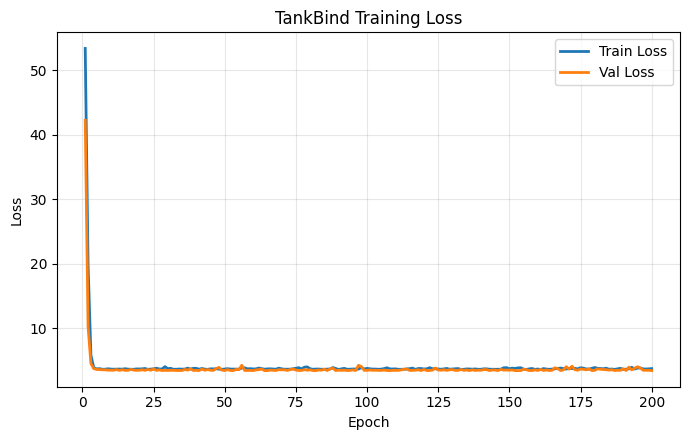

In [9]:
plot_loss_curves(train_loss_history, val_loss_history, title="TankBind Training Loss")

## 总结

- 技术路线：保留 TankBind 的"距离矩阵预测 -> 坐标恢复"路线。
- 教学骨架：统一为 `nn.Linear() + nn.ReLU()` 的简单 MLP。
- 训练输出：统一展示 train / val loss history。
- 主指标：`RMSD < 2A`。